# 02 — Tracking Comparison Across Profiles
#
# **Research question:** Does seeded browsing history change the
# tracking behavior a user encounters? Specifically:
#
#   1. Are seeded profiles tracked by MORE third-party hosts?
#   2. Do seeded profiles receive MORE persistent third-party cookies?
#   3. Are seeded profiles fingerprinted MORE aggressively?
#
# This notebook produces the headline figures and statistical tests
# that answer these questions.
#
# **Output:** Figures saved to `artifacts/figures/02_*.pdf`,
# statistics tables printed inline.

In [2]:
# %% Cell 1 — Setup
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd

from config import PROFILES, ALPHA, FIGURES_DIR
from src.utils.db import db_session

from src.analysis.trackers import (
    tracker_prevalence_by_profile,
    tracker_frequency_table,
    jaccard_similarity_matrix,
    differential_trackers,
)
from src.analysis.cookies import (
    cookie_counts_by_profile,
    cookie_lifespan_distribution,
    retargeting_cookie_presence,
    cookie_sync_summary,
)
from src.analysis.fingerprinting import (
    fingerprinter_summary,
    fingerprinter_top_scripts,
    detect_canvas_fingerprinters,
)
from src.analysis.statistics import (
    pairwise_battery,
    chi_square_batch,
    correct_pvalues,
)
from src.viz.tracker_plots import (
    apply_style,
    plot_prevalence_bars,
    plot_tracker_heatmap,
    plot_jaccard_matrix,
    plot_differential_trackers,
)
from src.viz.cookie_plots import (
    plot_first_vs_third_party,
    plot_lifespan_distribution,
    plot_retargeting_presence,
    plot_sync_summary,
    plot_fingerprinter_summary,
)

apply_style()
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

# Save all figures to a subdirectory of figures/ for this notebook.
FIG_DIR = FIGURES_DIR / "02_tracking_comparison"
FIG_DIR.mkdir(parents=True, exist_ok=True)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# ## Section 1: Tracker prevalence (network-level)
#
# RQ1: Does seeded history change how many third-party hosts are
# contacted during browsing?


⚠  analysis.duckdb not found — auto-initializing...
────────────────────────────────────────────────────────────
Initializing analysis.duckdb
────────────────────────────────────────────────────────────
Found 8 Parquet file(s):
  • ads.parquet                    (    0.0 MB)
  • callstacks.parquet             (    0.0 MB)
  • http_redirects.parquet         (    0.7 MB)
  • http_requests.parquet          (    6.7 MB)
  • http_responses.parquet         (    4.2 MB)
  • javascript.parquet             (    0.0 MB)
  • javascript_cookies.parquet     (    0.7 MB)
  • site_visits.parquet            (    0.0 MB)

Registering views:
  ✓ site_visits               (       200 rows)
  ✓ http_requests             (    33,308 rows)
  ✓ http_responses            (    29,015 rows)
  ✓ http_redirects            (     4,490 rows)
  ✓ javascript                (         0 rows)
  ✓ javascript_cookies        (    20,114 rows)
  ✓ callstacks                (         0 rows)
  ✓ ads                       ( 

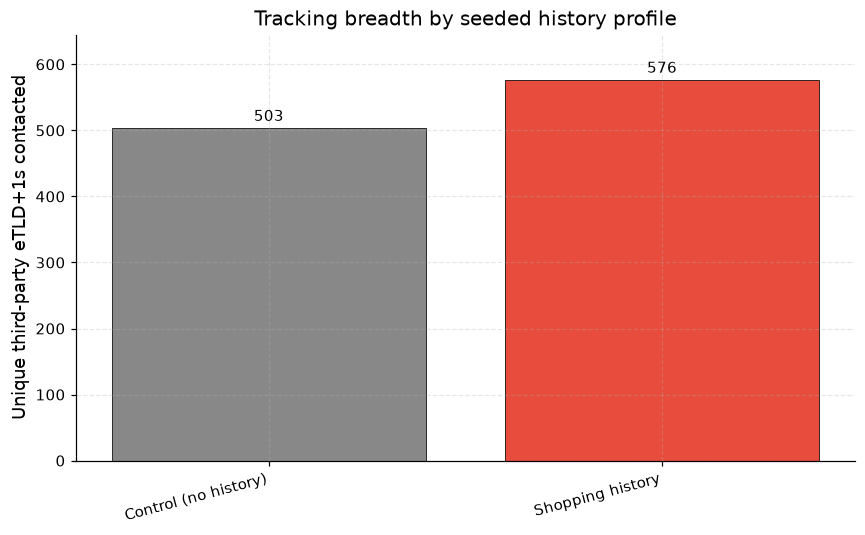

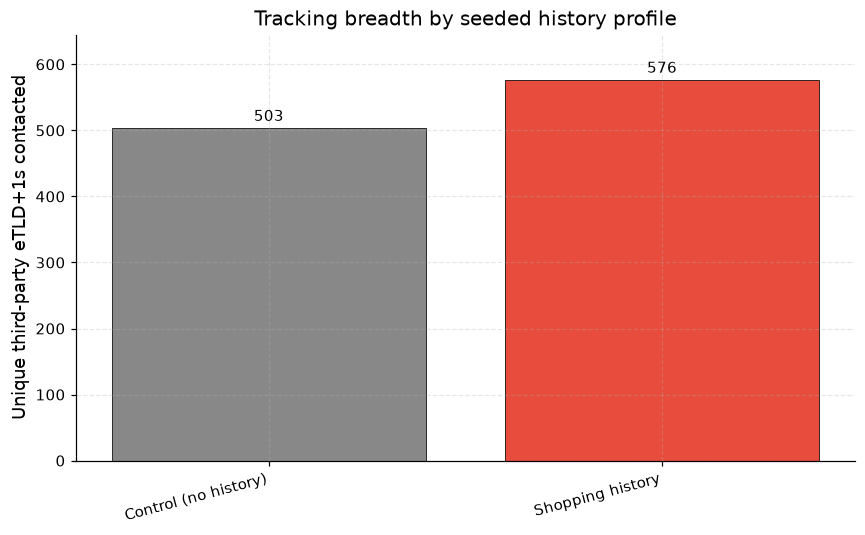

In [3]:
# %% Cell 2 — Headline metric
prev = tracker_prevalence_by_profile()
print("Tracker prevalence:")
print(prev.to_string(index=False))

plot_prevalence_bars(
    prev,
    value_col='n_unique_etld1',
    ylabel='Unique third-party eTLD+1s contacted',
    title='Tracking breadth by seeded history profile',
    save_path=FIG_DIR / 'fig01_tracker_breadth.pdf',
)

# ### Statistical test: do per-visit unique-host counts differ?
#
# We run Kruskal-Wallis (omnibus) followed by pairwise Mann-Whitney
# U tests with Bonferroni correction across the seeded-vs-control
# comparisons.

In [4]:
# %% Cell 3 — Statistics
stats_results = pairwise_battery('unique_hosts_per_visit')
print("\nStatistical results (Kruskal-Wallis + pairwise Mann-Whitney):")
print(stats_results[['test_name', 'comparison', 'statistic',
                     'p_value_corrected', 'effect_size',
                     'reject_null']].to_string(index=False))


Statistical results (Kruskal-Wallis + pairwise Mann-Whitney):
       test_name                                  comparison   statistic  p_value_corrected  effect_size  reject_null
Kruskal-Wallis H          2 profiles: unique_hosts_per_visit    0.036236           0.849030       0.0000        False
  Mann-Whitney U shopping vs control: unique_hosts_per_visit 4923.000000           0.849998       0.0154        False


# **Interpretation guide:**
#   - Kruskal-Wallis significant + all pairwise significant →
#     each seeded profile differs from control
#   - Kruskal-Wallis significant but only some pairs → only those
#     profiles' seeding had measurable effect
#   - Kruskal-Wallis non-significant → no overall effect; report
#     null result honestly


# ## Section 2: Tracker identity (which trackers, not just how many)

  ✓ Saved figure → C:\Users\finkgr1\Desktop\Tracking Analysis\artifacts\figures\02_tracking_comparison\fig02_tracker_heatmap.pdf


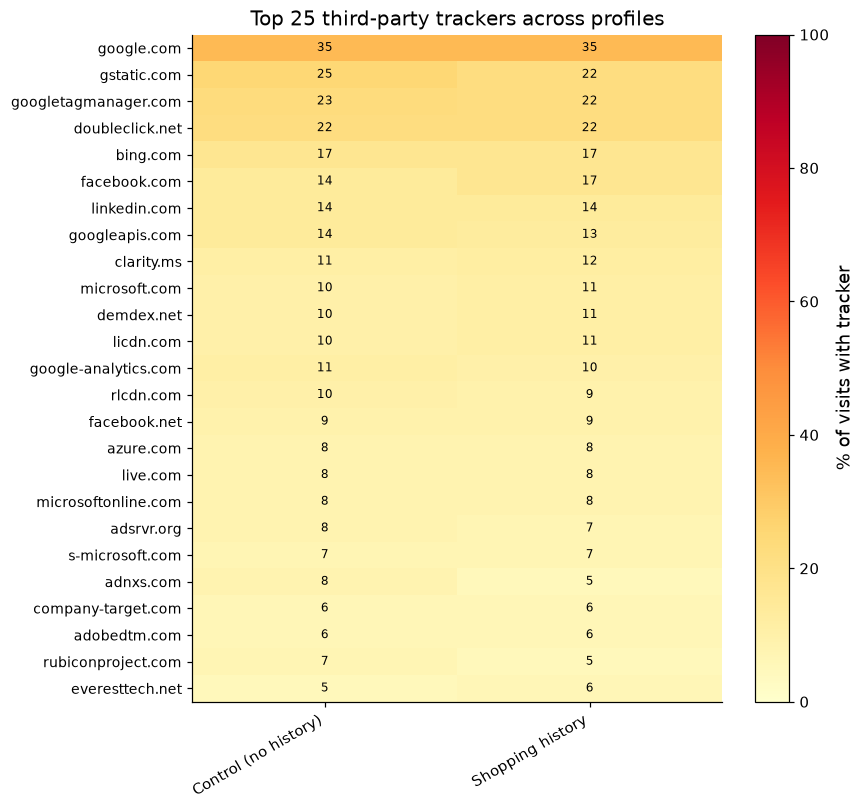

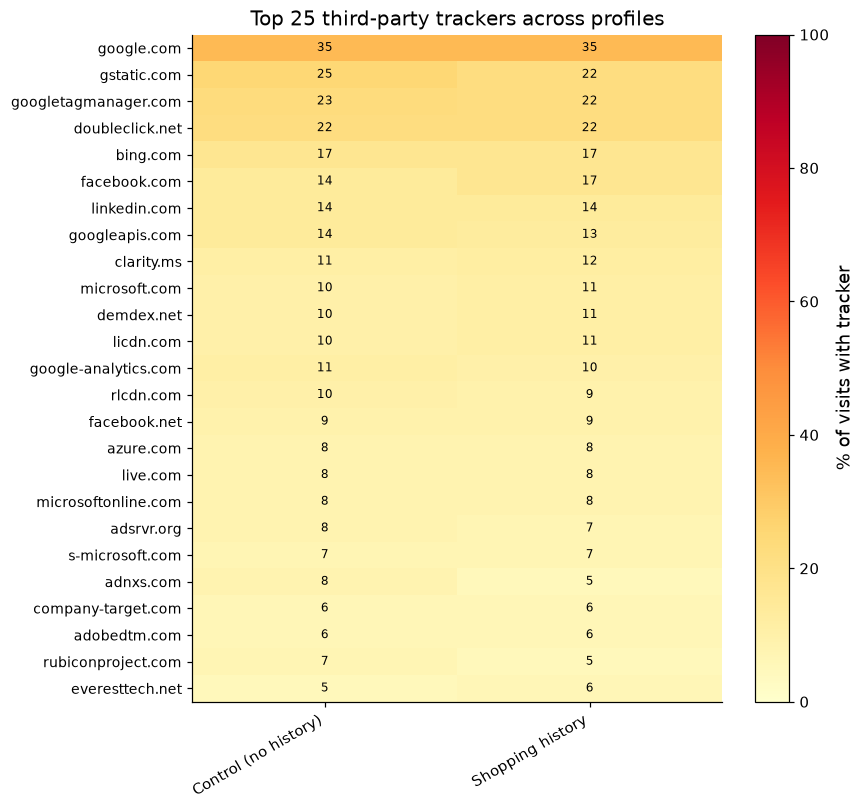

In [5]:
# %% Cell 4 — Top tracker heatmap
freq = tracker_frequency_table(top_n=25)
plot_tracker_heatmap(
    freq,
    top_n=25,
    title='Top 25 third-party trackers across profiles',
    save_path=FIG_DIR / 'fig02_tracker_heatmap.pdf',
)

Jaccard similarity of tracker sets:
          control  shopping
control     1.000     0.718
shopping    0.718     1.000
  ✓ Saved figure → C:\Users\finkgr1\Desktop\Tracking Analysis\artifacts\figures\02_tracking_comparison\fig03_jaccard.pdf


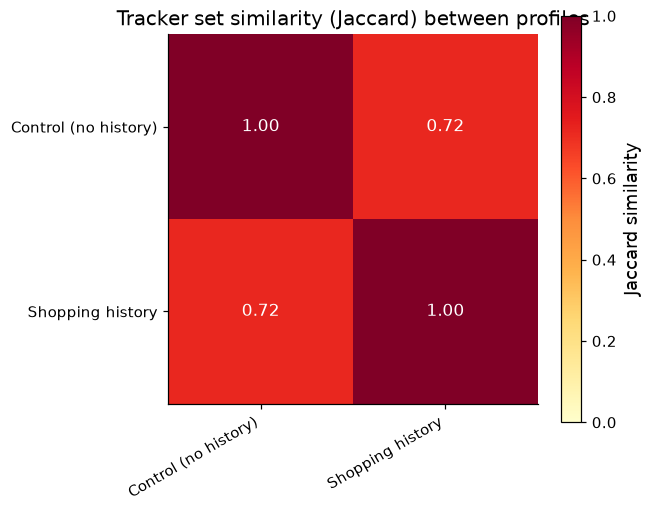

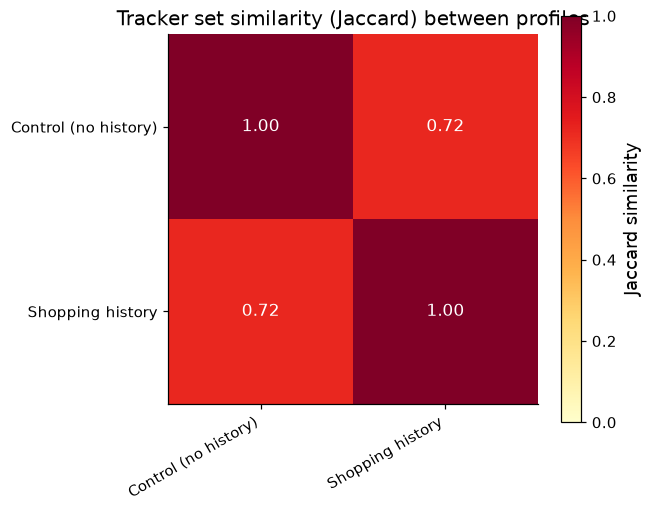

In [6]:
# %% Cell 5 — Set similarity
jaccard = jaccard_similarity_matrix()
print("Jaccard similarity of tracker sets:")
print(jaccard.round(3).to_string())

plot_jaccard_matrix(
    jaccard,
    save_path=FIG_DIR / 'fig03_jaccard.pdf',
)

# ## Section 3: Differential trackers (the "smoking gun" trackers)
#
# For each seeded profile, identify trackers that appear
# disproportionately compared to control, and confirm with
# chi-square tests.


Differential trackers: shopping vs control

Top 15 by lift:
                 etld1  visits_a  visits_b  lift  delta
          facebook.com      17.0      14.0 1.200    3.0
         bidswitch.net       5.0       4.0 1.200    1.0
cloudflareinsights.com       5.0       4.0 1.200    1.0
       everesttech.net       6.0       5.0 1.167    1.0
         microsoft.com      11.0      10.0 1.091    1.0
            demdex.net      11.0      10.0 1.091    1.0
             licdn.com      11.0      10.0 1.091    1.0
            clarity.ms      12.0      11.0 1.083    1.0
             yandex.ru       5.0       5.0 1.000    0.0
         cookielaw.org       5.0       5.0 1.000    0.0
             openx.net       5.0       5.0 1.000    0.0
          onetrust.com       5.0       5.0 1.000    0.0
          linkedin.com      14.0      14.0 1.000    0.0
          yastatic.net       5.0       5.0 1.000    0.0
   microsoftonline.com       8.0       8.0 1.000    0.0

Statistical confirmation:
  Of top 30 diff

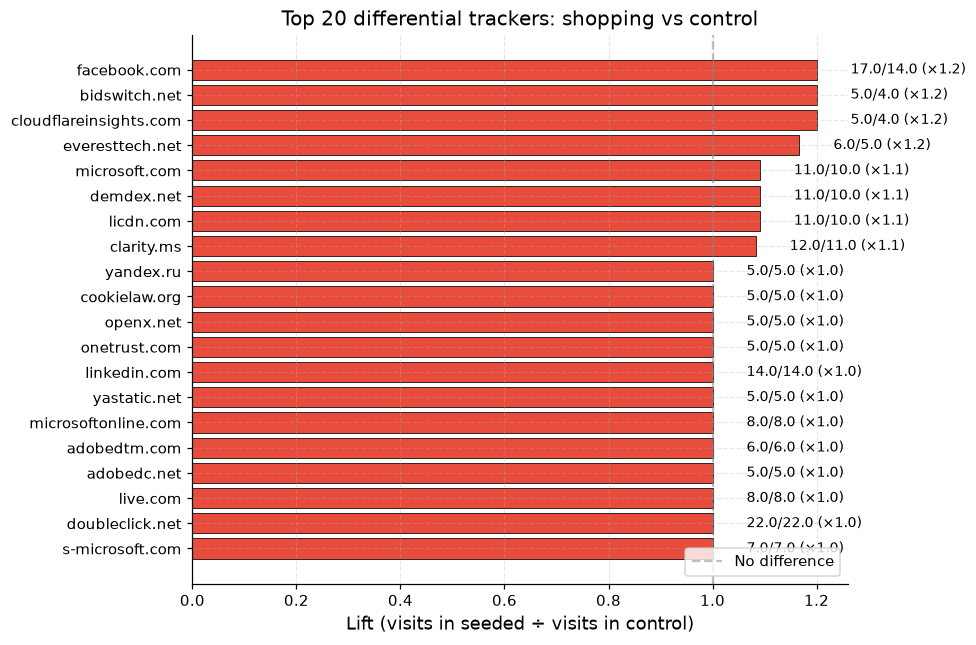

In [7]:
# %% Cell 6 — Per-seeded-profile differential analysis
for profile in PROFILES:
    if profile == 'control':
        continue
    print(f"\n{'='*60}")
    print(f"Differential trackers: {profile} vs control")
    print('='*60)

    diff = differential_trackers(profile, 'control', min_visits=5)
    print(f"\nTop 15 by lift:")
    print(diff.head(15)[['etld1', 'visits_a', 'visits_b', 'lift', 'delta']]
              .to_string(index=False))

    # Statistical confirmation on the top differential candidates
    top_trackers = diff.head(30)['etld1'].tolist()
    chi_results = chi_square_batch(profile, 'control', top_trackers)
    n_sig = chi_results['reject_null'].sum()
    print(f"\nStatistical confirmation:")
    print(f"  Of top 30 differential trackers, {n_sig} significant "
          f"after Bonferroni correction (α = {ALPHA})")

    sig_only = chi_results[chi_results['reject_null']].head(10)
    if not sig_only.empty:
        print(f"\nTop significant trackers ({profile}):")
        print(sig_only[['comparison', 'statistic',
                        'p_value_corrected', 'effect_size']]
                  .to_string(index=False))

    plot_differential_trackers(
        diff, f'{profile} vs control', top_n=20,
        save_path=FIG_DIR / f'fig04_diff_{profile}.pdf',
    )

# ## Section 4: Cookie behavior

Cookie counts by profile:
 profile  n_total  n_first_party  n_third_party  n_unique_hosts  pct_third_party
 control     8377         3114.0         5263.0             328            62.83
shopping    11737         3115.0         8622.0             371            73.46
  ✓ Saved figure → C:\Users\finkgr1\Desktop\Tracking Analysis\artifacts\figures\02_tracking_comparison\fig05_cookies_fp_tp.pdf


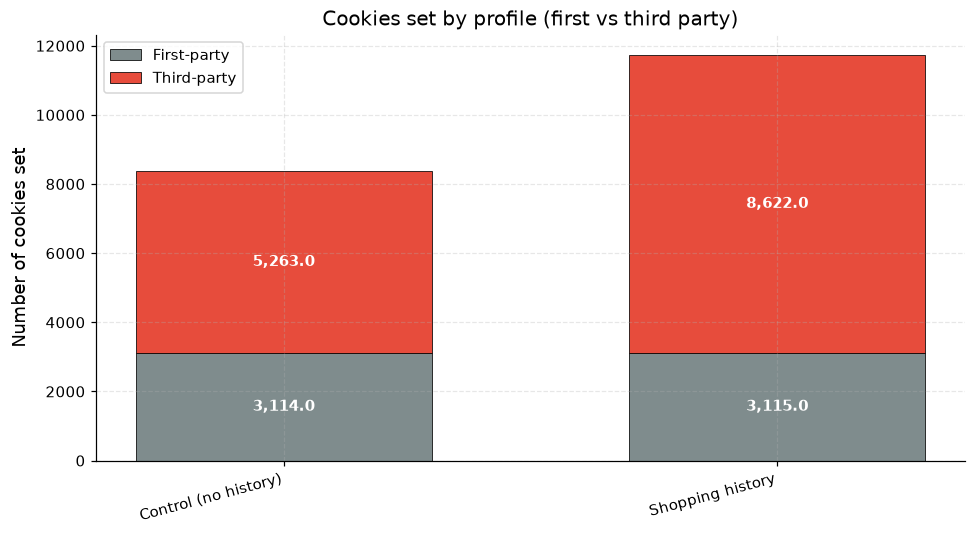

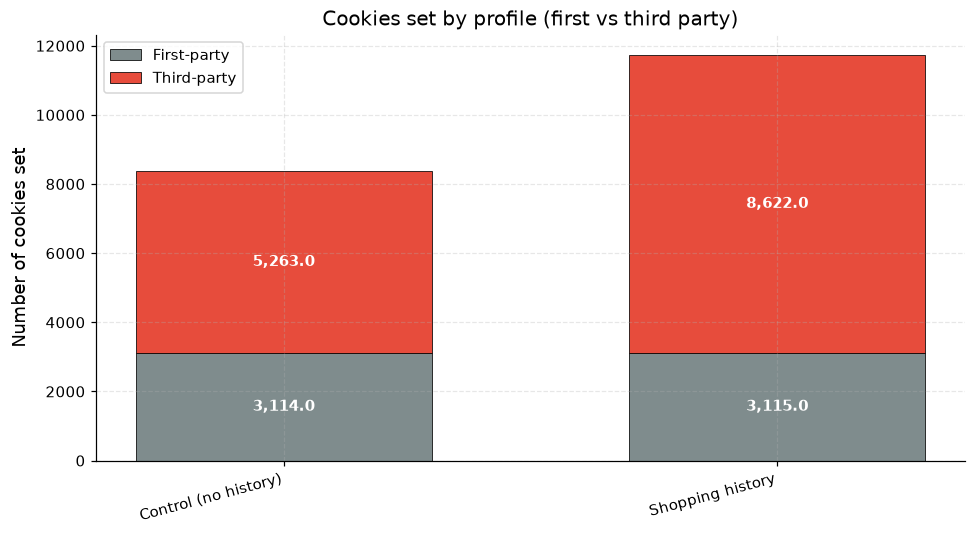

In [8]:
# %% Cell 7 — First vs third party
cookie_counts = cookie_counts_by_profile()
print("Cookie counts by profile:")
print(cookie_counts.to_string(index=False))

plot_first_vs_third_party(
    cookie_counts,
    save_path=FIG_DIR / 'fig05_cookies_fp_tp.pdf',
)


  ✓ Saved figure → C:\Users\finkgr1\Desktop\Tracking Analysis\artifacts\figures\02_tracking_comparison\fig06_cookie_lifespan_pct.pdf
  ✓ Saved figure → C:\Users\finkgr1\Desktop\Tracking Analysis\artifacts\figures\02_tracking_comparison\fig06_cookie_lifespan_raw.pdf


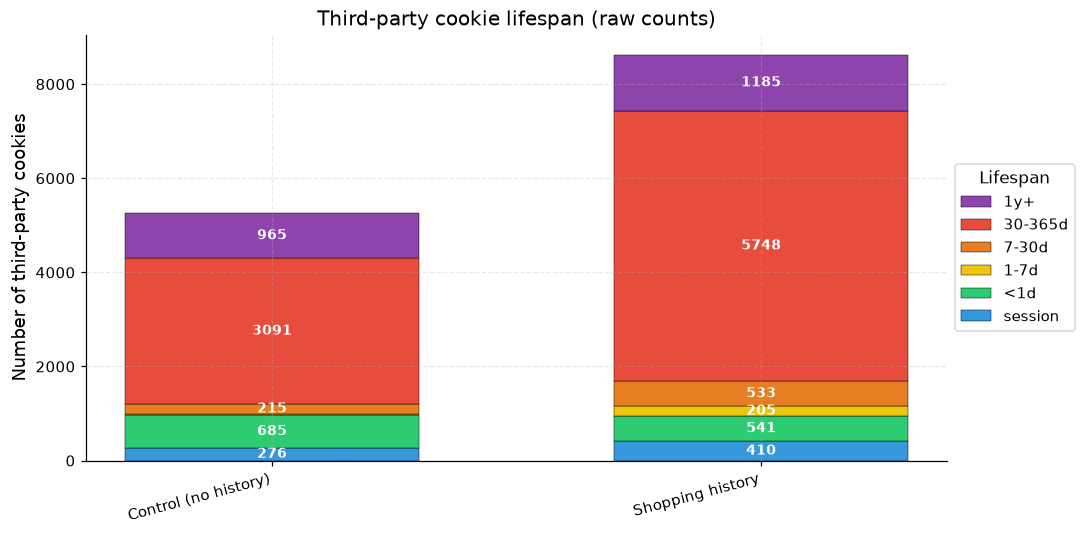

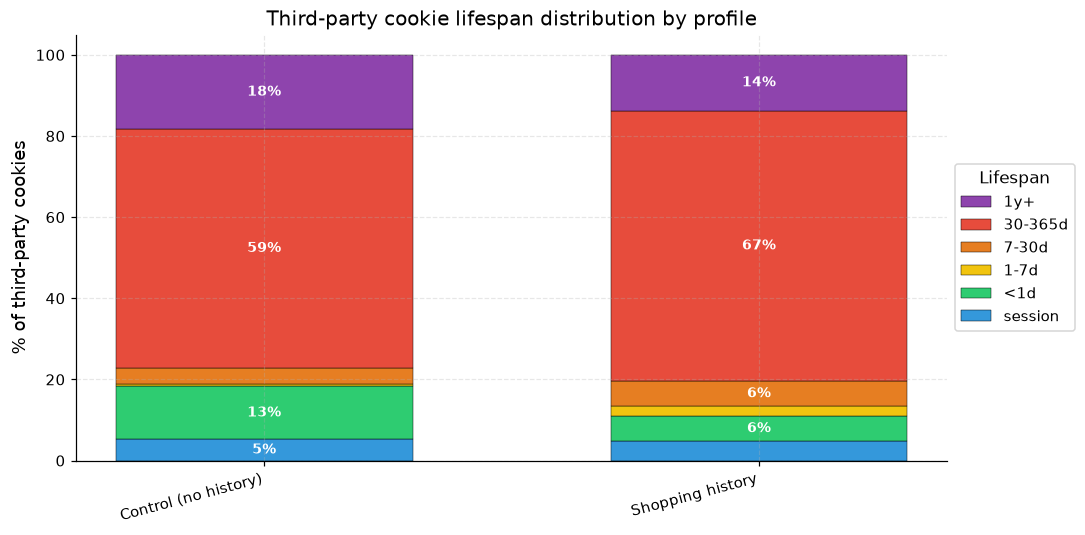

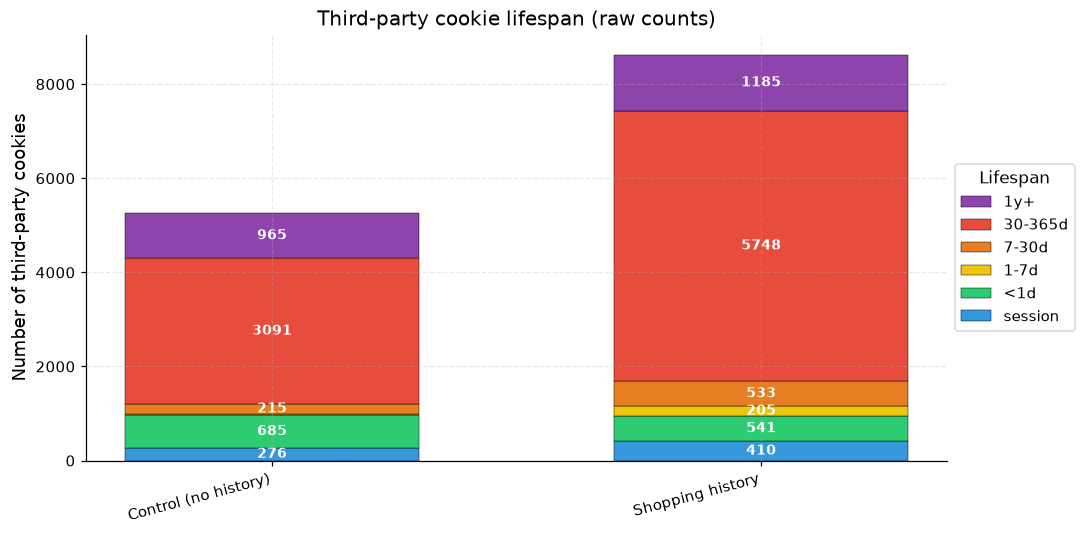

In [13]:
# %% Cell 8 — Lifespan distribution
lifespan = cookie_lifespan_distribution(third_party_only=True)
plot_lifespan_distribution(
    lifespan, normalize=True,
    save_path=FIG_DIR / 'fig06_cookie_lifespan_pct.pdf',
)
plot_lifespan_distribution(
    lifespan, normalize=False,
    title='Third-party cookie lifespan (raw counts)',
    save_path=FIG_DIR / 'fig06_cookie_lifespan_raw.pdf',
)

# ### Statistical test on third-party cookie counts

In [14]:
# %% Cell 9
tp_stats = pairwise_battery('third_party_cookies_per_visit')
print("\nThird-party cookies per visit (statistics):")
print(tp_stats[['test_name', 'comparison', 'p_value_corrected',
                'effect_size', 'reject_null']].to_string(index=False))


Third-party cookies per visit (statistics):
       test_name                                         comparison  p_value_corrected  effect_size  reject_null
Kruskal-Wallis H          2 profiles: third_party_cookies_per_visit           0.963019     0.000000        False
  Mann-Whitney U shopping vs control: third_party_cookies_per_visit           0.964964     0.004787        False


# ## Section 5: Retargeting network presence

Retargeting cookies by network and profile:
 profile         retargeter  n_cookies  n_visits_affected
 control rubiconproject.com        412                  7
 control       pubmatic.com        292                  6
 control        taboola.com        240                  3
 control          adnxs.com        193                  8
 control    casalemedia.com        118                  6
 control          rlcdn.com         60                 10
 control       outbrain.com         18                  3
 control      bidswitch.net         17                  3
 control         adroll.com         12                  1
 control    doubleclick.net         11                  4
 control         criteo.com          3                  1
shopping          adnxs.com       1944                  5
shopping rubiconproject.com        633                  5
shopping       pubmatic.com        343                  3
shopping        taboola.com        128                  4
shopping          rlcdn.com 

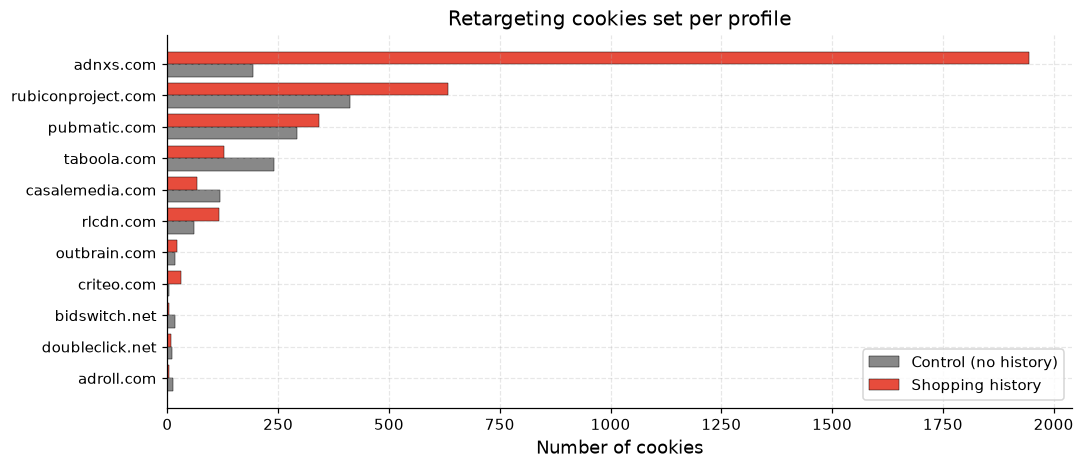

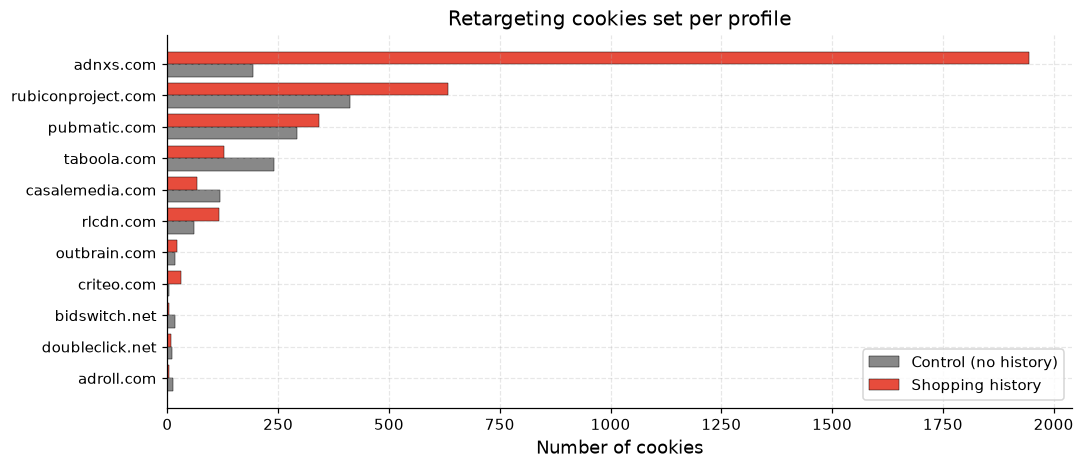

In [15]:
# %% Cell 10
retarg = retargeting_cookie_presence()
print("Retargeting cookies by network and profile:")
print(retarg.to_string(index=False))

plot_retargeting_presence(
    retarg, metric='n_cookies',
    title='Retargeting cookies set per profile',
    save_path=FIG_DIR / 'fig07_retargeting_cookies.pdf',
)

# ## Section 6: Cookie syncing

Cookie sync activity:
 profile  n_sync_events  n_visits_with_syncs  avg_hosts_per_sync
 control             58                   25                2.31
shopping             56                   21                2.29
  ✓ Saved figure → C:\Users\finkgr1\Desktop\Tracking Analysis\artifacts\figures\02_tracking_comparison\fig08_sync_summary.pdf


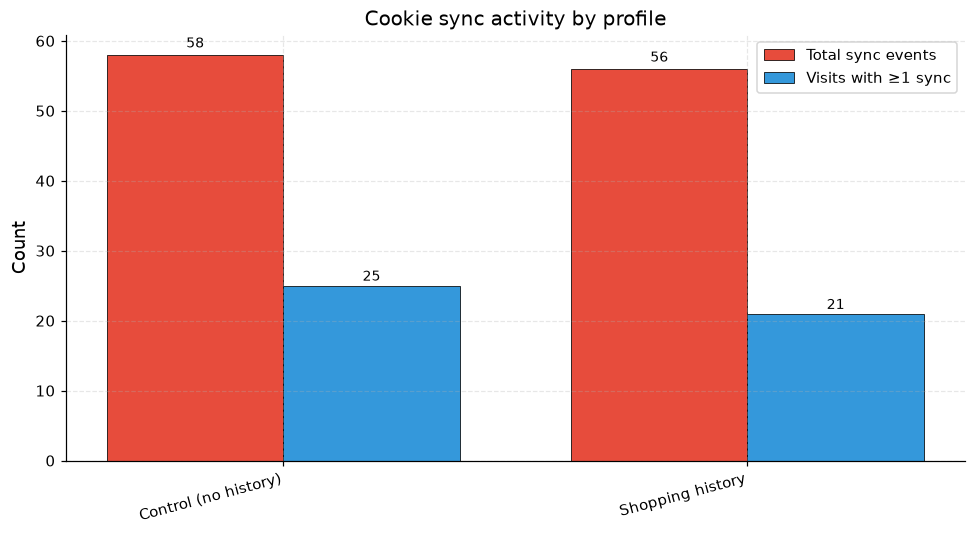

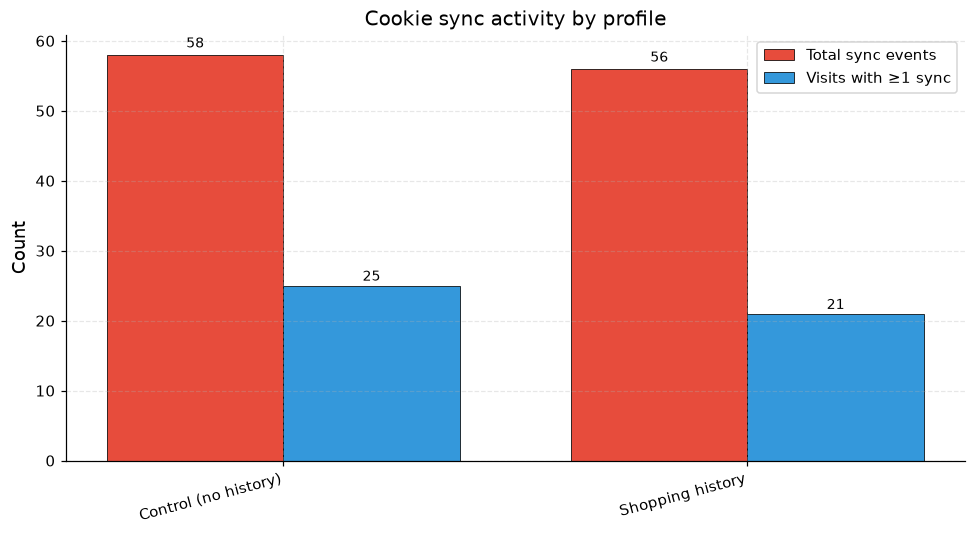

In [16]:
# %% Cell 11
syncs = cookie_sync_summary()
print("Cookie sync activity:")
print(syncs.to_string(index=False))

plot_sync_summary(
    syncs,
    save_path=FIG_DIR / 'fig08_sync_summary.pdf',
)

# ## Section 7: Fingerprinting
#
# Even when cookies are cleared, fingerprinting persists identity.
# Do seeded profiles encounter more aggressive fingerprinting?

Fingerprinting scripts encountered:
 profile  n_canvas_fp_scripts  n_audio_fp_scripts  n_navigator_fp_scripts  canvas_fp_visits  audio_fp_visits  navigator_fp_visits
 control                    0                   0                       0                 0                0                    0
shopping                    0                   0                       0                 0                0                    0
  ✓ Saved figure → C:\Users\finkgr1\Desktop\Tracking Analysis\artifacts\figures\02_tracking_comparison\fig09_fingerprinter_summary.pdf


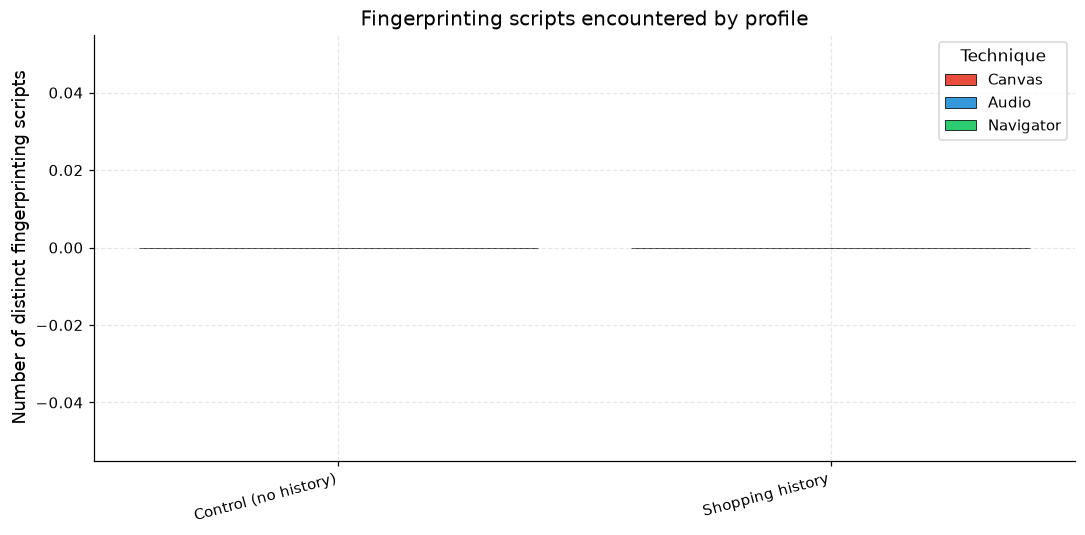

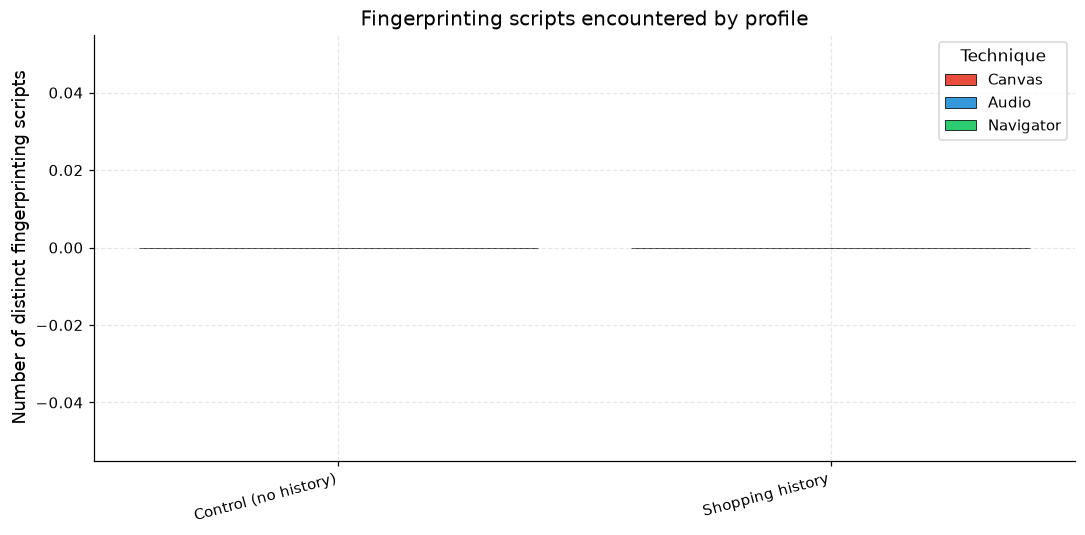

In [17]:
# %% Cell 12 — Summary
fp_summary = fingerprinter_summary()
print("Fingerprinting scripts encountered:")
print(fp_summary.to_string(index=False))

plot_fingerprinter_summary(
    fp_summary,
    save_path=FIG_DIR / 'fig09_fingerprinter_summary.pdf',
)

In [18]:
# %% Cell 13 — Top scripts
top_fp = fingerprinter_top_scripts(top_n=20)
print("\nTop 20 fingerprinting scripts (all profiles):")
print(top_fp.to_string(index=False))



Top 20 fingerprinting scripts (all profiles):
Empty DataFrame
Columns: [script_url, technique, total_visits, profiles_seen]
Index: []


# ## Section 8: Summary of findings

In [19]:
# %% Cell 14
print("=" * 70)
print("SUMMARY OF FINDINGS")
print("=" * 70)
print(f"\nProfiles analyzed: {', '.join(PROFILES)}")
print(f"Significance threshold: α = {ALPHA} (Bonferroni-corrected)")

print("\n— RQ1 (Network) —")
print(f"  Unique trackers per profile:")
for _, row in prev.iterrows():
    print(f"    {row['profile']:10s}: {row['n_unique_etld1']:4d} eTLD+1s, "
          f"{row['etld1_per_visit']:.1f} per visit")
n_sig_network = (stats_results[stats_results['test_name'] == 'Mann-Whitney U']
                 ['reject_null'].sum())
print(f"  {n_sig_network} of {len(PROFILES) - 1} seeded profiles show "
      f"significantly different unique-host counts vs control.")

print("\n— RQ2 (Cookies) —")
for _, row in cookie_counts.iterrows():
    print(f"    {row['profile']:10s}: {row['n_third_party']:5d} 3p cookies "
          f"({row['pct_third_party']}%)")

print("\n— RQ3 (Fingerprinting) —")
for _, row in fp_summary.iterrows():
    total = (row['n_canvas_fp_scripts'] + row['n_audio_fp_scripts']
             + row['n_navigator_fp_scripts'])
    print(f"    {row['profile']:10s}: {total:3d} fingerprinting scripts "
          f"(canvas={row['n_canvas_fp_scripts']}, "
          f"audio={row['n_audio_fp_scripts']}, "
          f"navigator={row['n_navigator_fp_scripts']})")

print("\nAll figures saved to:", FIG_DIR.resolve())

SUMMARY OF FINDINGS

Profiles analyzed: control, shopping
Significance threshold: α = 0.05 (Bonferroni-corrected)

— RQ1 (Network) —
  Unique trackers per profile:
    control   :  503 eTLD+1s, 5.0 per visit
    shopping  :  576 eTLD+1s, 5.8 per visit
  0 of 1 seeded profiles show significantly different unique-host counts vs control.

— RQ2 (Cookies) —


ValueError: Unknown format code 'd' for object of type 'float'